# 02 · Training

## 0 · Local Setup  

In [143]:
from pathlib import Path
import sys, yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(f'Cannot find project root from {Path.cwd()}')

sys.path.insert(0, str(PROJECT_ROOT))

missing = []
for pkg in ['pretty_midi', 'yaml']:
    try:
        __import__(pkg)
    except Exception:
        missing.append(pkg)
if missing:
    print(f'Missing packages: {missing}')
    print('Install with: pip install pretty_midi PyYAML')

with open(PROJECT_ROOT / 'configs' / 'base.yaml') as f:
    config = yaml.safe_load(f)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('Config:', config)

PROJECT_ROOT = /root/autodl-tmp/music-style-transfer
Config: {'model': {'input_dim': 89, 'hidden_dim': 256, 'z_p_dim': 64, 'z_r_dim': 64}, 'training': {'batch_size': 128, 'lr': 0.0002, 'beta_start': 0.0001, 'beta_end': 0.03, 'beta_epochs': 30, 'gamma': 0.6, 'swap_recon_ratio': 0.0, 'style_cls_weight': 0.2, 'transfer_style_weight': 0.2, 'adv_style_weight': 0.15, 'content_consistency_weight': 0.2, 'orth_weight': 0.01, 'grl_lambda': 1.0, 'early_stopping_metric': 'val/total', 'early_stopping_patience': 0, 'early_stopping_min_delta': 0.0, 'epochs': 100, 'pos_weight': 5.0, 'swap_warmup_epochs': 10, 'use_amp': True}, 'data': {'seq_len': 32, 'fs': 12, 'pitch_low': 21, 'pitch_high': 109}}


## 1 · Imports & Device

In [144]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader

# Project modules
from src.models.ec2vae       import EC2VAE
from src.training.loss       import compute_loss
from src.training.scheduler  import BetaScheduler
from src.training.trainer    import Trainer
from src.data.dataset        import MusicDataset

# Paths
DATA_DIR = Path(PROJECT_ROOT) / 'data' / 'processed'
GENRES   = ['jazz', 'pop']

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce RTX 3090
VRAM: 25.3 GB


## 2 · Beta Schedule Visualisation

Verify the annealing curve before training.

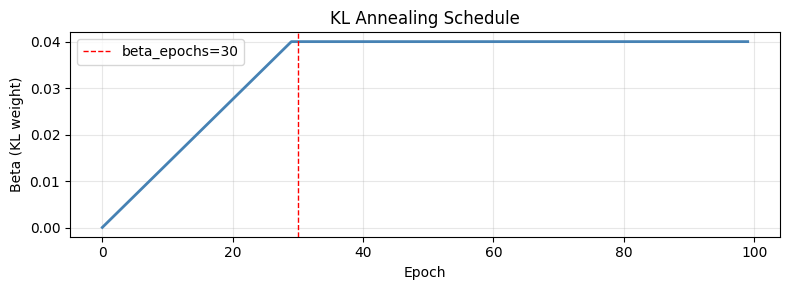

beta at epoch   0: 0.0001
beta at epoch  25: 0.0345
beta at epoch  50: 0.0400
beta at epoch  99: 0.0400


In [ ]:
scheduler = BetaScheduler.from_config(config)
total_epochs = config['training']['epochs']
betas = scheduler.schedule(total_epochs)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(total_epochs), betas, color='steelblue', linewidth=2)
ax.axvline(config['training']['beta_epochs'], color='red', linestyle='--',
           linewidth=1, label=f"beta_epochs={config['training']['beta_epochs']}")
ax.set_xlabel('Epoch')
ax.set_ylabel('Beta (KL weight)')
ax.set_title('KL Annealing Schedule')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/beta_schedule.png',
            bbox_inches='tight', dpi=120)
plt.show()

for ep in [0, total_epochs//4, total_epochs//2, total_epochs-1]:
    print(f'beta at epoch {ep:>3}: {betas[ep]:.4f}')

## 3 · DataLoaders

In [ ]:
BATCH_SIZE = config['training']['batch_size']

import os
_cpu = os.cpu_count() or 4
NUM_WORKERS = min(8, max(2, _cpu // 2))
loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)
if NUM_WORKERS > 0:
    loader_kwargs.update(dict(
        persistent_workers=True,
        prefetch_factor=4,
    ))

train_ds = MusicDataset(str(DATA_DIR), GENRES, split='train', augment=False)
val_ds   = MusicDataset(str(DATA_DIR), GENRES, split='val')

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    **loader_kwargs,
 )
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
    **loader_kwargs,
 )

print(f'Train: {len(train_ds):>6} segments  ({len(train_loader)} batches)')
print(f'Val:   {len(val_ds):>6} segments  ({len(val_loader)} batches)')
print(f'Per genre (train): {train_ds.genre_counts()}')
print(f'Workers: {NUM_WORKERS}, batch_size={BATCH_SIZE}')

Train: 166948 segments  (1304 batches)
Val:    20868 segments  (164 batches)
Per genre (train): {'jazz': 84120, 'pop': 82828}
Workers: 8, batch_size=128


## 4 · Model Initialisation

In [ ]:
model = EC2VAE.from_config(config).to(device)

n_params = model.count_parameters()
print(f'EC2VAE — trainable parameters: {n_params:,}')

x_dummy = torch.zeros(2, config['data']['seq_len'], config['model']['input_dim']).to(device)
out     = model(x_dummy, do_swap=True)
print(f'logits shape       : {tuple(out.logits.shape)}')
print(f'rhythm_pred shape  : {tuple(out.rhythm_pred.shape)}')
print(f'swap_logits shape  : {tuple(out.swap_logits.shape)}')
print('Forward pass ✓')

EC2VAE — trainable parameters: 2,844,762
logits shape       : (2, 32, 89)
rhythm_pred shape  : (2, 32)
swap_logits shape  : (2, 32, 89)
Forward pass ✓


## 5 · Train  *(auto-resumes from `latest.pt` if it exists)*

Re-run this cell after restarting the notebook kernel — `trainer.load_latest()` picks up where it left off.

---
## 5 · Training Configuration

**Edit `EPOCHS_TO_RUN` to control how many epochs to train this session.**  
- Set to `None` to run until `config['training']['epochs']` (full schedule).
- Set to any integer (e.g. `30`) to stop after that many *total* epochs.
- `CHECKPOINT_BASE` controls where checkpoints are stored (for SSH reconnect safety).
- Re-running Cell 6 after reconnect/kernel restart will resume automatically from where it left off.

> `FRESH_START = True` deletes existing checkpoints in the selected checkpoint directory and trains from epoch 0.

In [ ]:
EPOCHS_TO_RUN = 68     
FRESH_START   = False  

ADV_STYLE_WEIGHT = 0.06
CONTENT_CONSISTENCY_WEIGHT = 0.40

CHECKPOINT_BASE = None  

import os
from pathlib import Path

_base = CHECKPOINT_BASE or os.environ.get('MST_CHECKPOINT_BASE')
if _base is None:
    trainer_project_root = Path(PROJECT_ROOT).resolve()
else:
    trainer_project_root = Path(_base).expanduser().resolve()
trainer_project_root.mkdir(parents=True, exist_ok=True)

ckpt_dir = trainer_project_root / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)

if FRESH_START:
    for fname in ['latest.pt', 'best_model.pt']:
        p = ckpt_dir / fname
        if p.exists():
            p.unlink()
            print(f'Removed {p}')
    print('Fresh start — training from epoch 0.')

old_adv = config['training'].get('adv_style_weight', None)
old_cc  = config['training'].get('content_consistency_weight', None)
config['training']['adv_style_weight'] = float(ADV_STYLE_WEIGHT)
config['training']['content_consistency_weight'] = float(CONTENT_CONSISTENCY_WEIGHT)
print(f"Retune weights: adv_style_weight {old_adv} -> {config['training']['adv_style_weight']}")
print(f"Retune weights: content_consistency_weight {old_cc} -> {config['training']['content_consistency_weight']}")

_base_epochs = config['training']['epochs']
if EPOCHS_TO_RUN is not None:
    config['training']['epochs'] = int(EPOCHS_TO_RUN)
    print(f'Epochs override: will train up to epoch {EPOCHS_TO_RUN} '
          f'(base.yaml has {_base_epochs})')
else:
    print(f'Epochs: {_base_epochs} (from base.yaml)')

print(f'Trainer project root: {trainer_project_root}')
print(f'Checkpoints dir     : {ckpt_dir}')
print('Resume later: set FRESH_START=False and increase EPOCHS_TO_RUN, then rerun training cell.')

Retune weights: adv_style_weight 0.15 -> 0.06
Retune weights: content_consistency_weight 0.2 -> 0.4
Epochs override: will train up to epoch 68 (base.yaml has 100)
Trainer project root: /root/autodl-tmp/music-style-transfer
Checkpoints dir     : /root/autodl-tmp/music-style-transfer/checkpoints
Resume later: set FRESH_START=False and increase EPOCHS_TO_RUN, then rerun training cell.


In [148]:
import importlib
import src.training.trainer as trainer_module
importlib.reload(trainer_module)

trainer = trainer_module.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    device=device,
    project_root=str(trainer_project_root),
)

# Auto-resume from latest checkpoint if available
trainer.load_latest()

# Full run mode: do not cap epochs inside this cell.
SHORT_RUN_EPOCHS = None
if SHORT_RUN_EPOCHS is not None and SHORT_RUN_EPOCHS > 0:
    target_total = min(trainer.total_epochs, trainer.start_epoch + int(SHORT_RUN_EPOCHS))
    trainer.total_epochs = target_total
    print(f'Quick run enabled: start={trainer.start_epoch}, stop={trainer.total_epochs-1}')

# Run training from start_epoch (safe to rerun after reconnect/kernel restart)
history = trainer.train()

Resumed from epoch 59  (best val/total=0.2608)
Training EC2-VAE  |  epochs 60–67  |  device=cuda  |  amp=True
Epoch  60/67  β=0.0300  (71s)
  train: total=0.1985  recon=0.1152  kl=0.5492  rhythm=0.0039  swap_recon=0.1472  swap_rhythm=0.0039  style_cls=0.0404  style_adv=0.7060  content_cons=0.0092  orth=0.0040
  val:   total=0.2484  recon=0.1114  kl=0.5296  rhythm=0.0029  style_cls=0.3877  style_adv=0.6972  orth=0.0017
  ✓ New best model saved  (val/total=0.2484, val/total=0.2484)
Epoch  61/67  β=0.0300  (69s)
  train: total=0.1975  recon=0.1148  kl=0.5517  rhythm=0.0038  swap_recon=0.1471  swap_rhythm=0.0038  style_cls=0.0385  style_adv=0.7072  content_cons=0.0091  orth=0.0045
  val:   total=0.2510  recon=0.1111  kl=0.5556  rhythm=0.0069  style_cls=0.3915  style_adv=0.6799  orth=0.0021
Epoch  62/67  β=0.0300  (68s)
  train: total=0.1988  recon=0.1145  kl=0.5741  rhythm=0.0038  swap_recon=0.1481  swap_rhythm=0.0038  style_cls=0.0391  style_adv=0.7117  content_cons=0.0100  orth=0.0057
  

## 6 · Loss Curves

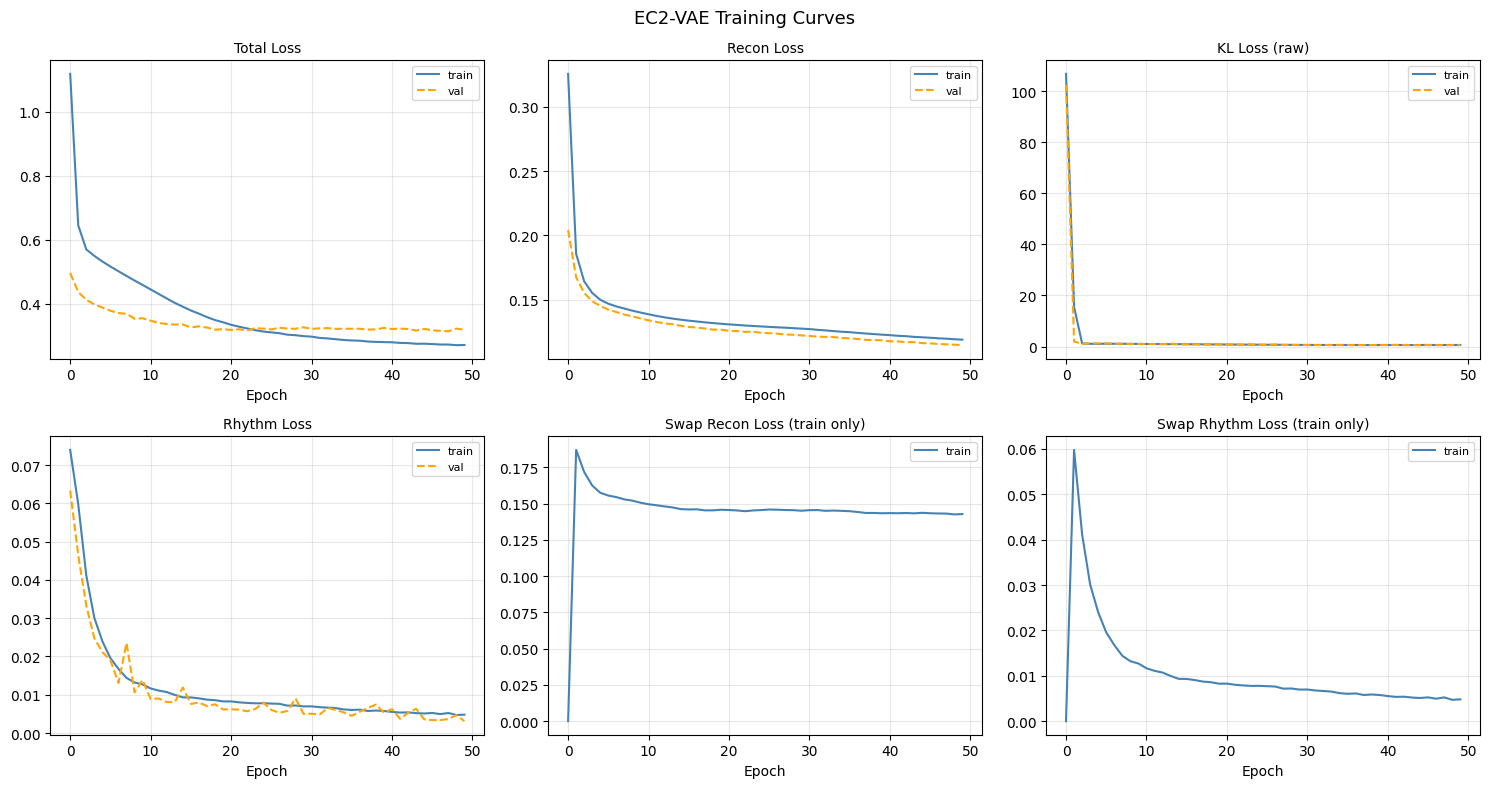

In [131]:
# Load history from trainer (works even after resume)
history = trainer.history
epochs  = [h['epoch'] for h in history]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    ('loss/total',       'val/total',   'Total Loss'),
    ('loss/recon',       'val/recon',   'Recon Loss'),
    ('loss/kl',          'val/kl',      'KL Loss (raw)'),
    ('loss/rhythm',      'val/rhythm',  'Rhythm Loss'),
    ('loss/swap_recon',  None,          'Swap Recon Loss (train only)'),
    ('loss/swap_rhythm', None,          'Swap Rhythm Loss (train only)'),
]

for ax, (train_key, val_key, title) in zip(axes.flat, pairs):
    train_vals = [h[train_key] for h in history]
    ax.plot(epochs, train_vals, label='train', color='steelblue')
    if val_key:
        val_vals = [h[val_key] for h in history]
        ax.plot(epochs, val_vals, label='val', color='orange', linestyle='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('EC2-VAE Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/loss_curves.png',
            bbox_inches='tight', dpi=120)
plt.show()

## 7 · Beta Annealing Curve (actual)

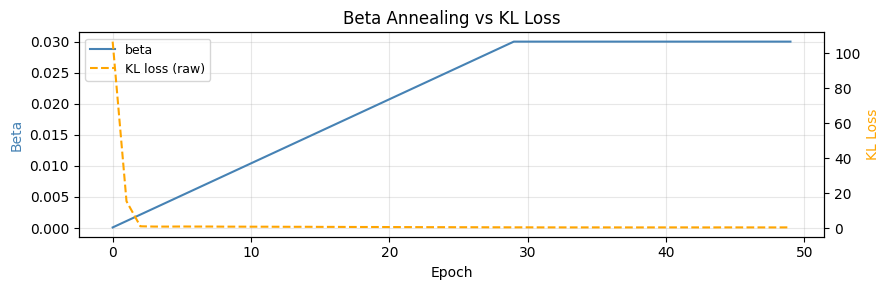

KL loss (final epoch) = 0.6154  ✓


In [132]:
betas_actual = [h['beta'] for h in history]
kl_vals      = [h['loss/kl'] for h in history]

fig, ax1 = plt.subplots(figsize=(9, 3))
ax2 = ax1.twinx()

ax1.plot(epochs, betas_actual, color='steelblue', label='beta')
ax2.plot(epochs, kl_vals,      color='orange',    label='KL loss (raw)', linestyle='--')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Beta', color='steelblue')
ax2.set_ylabel('KL Loss', color='orange')
ax1.set_title('Beta Annealing vs KL Loss')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/beta_vs_kl.png',
            bbox_inches='tight', dpi=120)
plt.show()

# Collapse check: if KL stays near 0 throughout, posterior has collapsed
final_kl = kl_vals[-1]
if final_kl < 0.01:
    print(f'⚠ WARNING: KL loss = {final_kl:.4f} — possible posterior collapse!')
    print('  → Try reducing beta_end or increasing beta_epochs in base.yaml')
else:
    print(f'KL loss (final epoch) = {final_kl:.4f}  ✓')

## 8 · Mode Collapse Check

Run a few val batches through the best model and check output density.  
If the model has collapsed to silent output, output density will be ~0.

In [ ]:
best_ckpt = torch.load(f'{PROJECT_ROOT}/checkpoints/best_model.pt',
                       map_location=device)
model.load_state_dict(best_ckpt['model_state'])
model.eval()

output_densities = []
input_densities  = []

with torch.no_grad():
    for i, (x, rhythm_gt, _) in enumerate(val_loader):
        if i >= 5:
            break
        x = x.to(device)
        out = model(x, do_swap=False)
        probs = torch.sigmoid(out.logits)         
        pred_binary = (probs > 0.5).float()
        output_densities.append(pred_binary[:, :, :88].mean().item())
        input_densities.append(x[:, :, :88].mean().item())

avg_out   = np.mean(output_densities)
avg_input = np.mean(input_densities)

print(f'Input  note density (val): {avg_input:.4f}')
print(f'Output note density (val): {avg_out:.4f}')

if avg_out < 0.005:
    print('⚠ WARNING: Output is nearly silent — possible mode collapse!')
    print('  → Check pos_weight in loss.py (should be ~5.0)')
    print('  → Check beta annealing is not too fast')
elif avg_out / avg_input < 0.3:
    print('⚠ Output density is low relative to input — may be under-reconstructing')
else:
    print('Output density looks healthy ✓')

Input  note density (val): 0.0641
Output note density (val): 0.0734
Output density looks healthy ✓


## 9 · Reconstruction Visualisation

Side-by-side: input piano roll vs reconstructed output for one sample per genre.

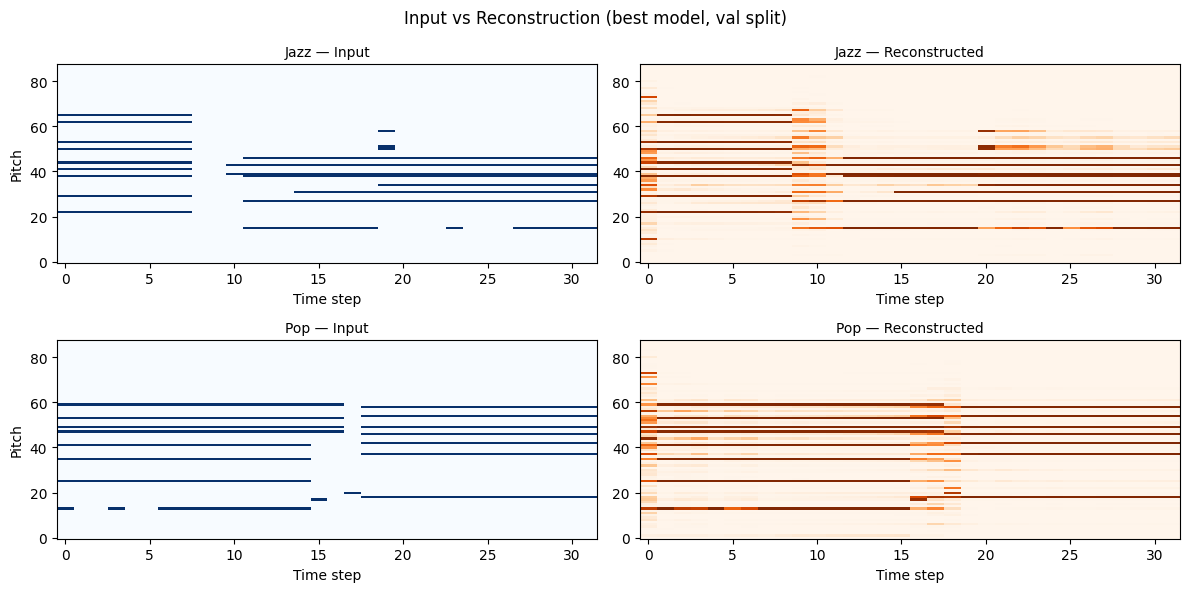

In [ ]:
from src.data.dataset import MusicDataset

val_ds_viz = MusicDataset(str(DATA_DIR), GENRES, split='val')
SEQ_LEN    = config['data']['seq_len']

fig, axes = plt.subplots(len(GENRES), 2, figsize=(12, 3 * len(GENRES)))
model.eval()

offsets = [0]
for g in GENRES[:-1]:
    import numpy as np
    counts = val_ds_viz.genre_counts()
    offsets.append(offsets[-1] + counts[g])

with torch.no_grad():
    for row, (genre, offset) in enumerate(zip(GENRES, offsets)):
        x_np, _, _ = val_ds_viz[offset + 3]
        x_t = x_np.unsqueeze(0).to(device)   

        out   = model(x_t, do_swap=False)
        recon = torch.sigmoid(out.logits).squeeze(0).cpu().numpy()   

        ax_in  = axes[row][0]
        ax_out = axes[row][1]

        ax_in.imshow(x_np[:, :88].numpy().T, aspect='auto', origin='lower',
                     cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
        ax_in.set_title(f'{genre.capitalize()} — Input', fontsize=10)
        ax_in.set_ylabel('Pitch')

        ax_out.imshow(recon[:, :88].T, aspect='auto', origin='lower',
                      cmap='Oranges', interpolation='nearest', vmin=0, vmax=1)
        ax_out.set_title(f'{genre.capitalize()} — Reconstructed', fontsize=10)

        for ax in [ax_in, ax_out]:
            ax.set_xlabel('Time step')

fig.suptitle('Input vs Reconstruction (best model, val split)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/figures/reconstruction_viz.png',
            bbox_inches='tight', dpi=120)
plt.show()

## 10 · Training Summary

In [149]:
best_epoch = min(history, key=lambda h: h['val/total'])

print('=' * 55)
print('Training Summary')
print('=' * 55)
print(f"  Epochs trained    : {len(history)}")
print(f"  Epoch range       : {history[0]['epoch']} → {history[-1]['epoch']}")
print(f"  Best epoch        : {best_epoch['epoch']}")
print(f"  Best val loss     : {best_epoch['val/total']:.4f}")
print(f"  Final train loss  : {history[-1]['loss/total']:.4f}")
print(f"  Final val loss    : {history[-1]['val/total']:.4f}")
print(f"  Final KL (raw)    : {history[-1]['loss/kl']:.4f}")
print(f"  Final rhythm loss : {history[-1]['loss/rhythm']:.4f}")
print(f"  swap_weight final : {history[-1].get('swap_weight', 'n/a')}")
print('=' * 55)
print(f"\nCheckpoints saved to: {PROJECT_ROOT}/checkpoints/")
print('  best_model.pt  — use for evaluation & demo')
print('  latest.pt      — use for resuming training')
print(f'\nTo continue training: set EPOCHS_TO_RUN={history[-1]["epoch"]+1+30} and re-run.')
print('\n✓ Session complete. Proceed to 03_eval.ipynb or continue training.')

Training Summary
  Epochs trained    : 68
  Epoch range       : 0 → 67
  Best epoch        : 64
  Best val loss     : 0.2459
  Final train loss  : 0.1967
  Final val loss    : 0.2504
  Final KL (raw)    : 0.5793
  Final rhythm loss : 0.0037
  swap_weight final : 1.0

Checkpoints saved to: /root/autodl-tmp/music-style-transfer/checkpoints/
  best_model.pt  — use for evaluation & demo
  latest.pt      — use for resuming training

To continue training: set EPOCHS_TO_RUN=98 and re-run.

✓ Session complete. Proceed to 03_eval.ipynb or continue training.
